# Regressão Linear com Dados de Energia Solar

## Exercício de Preparação — São Paulo, SP

**Fonte dos dados:** PVGIS — Photovoltaic Geographical Information System

**Localização:** São Paulo - SP  
**Latitude:** -23.5505  
**Longitude:** -46.6333  
**Período consultado:** 2023  
**Potência instalada considerada:** 1 kWp  
**Perdas consideradas:** 14%



## 1. Importação das bibliotecas




In [1]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## 2. Obtenção dos dados pela API do PVGIS

A localização escolhida para a atividade é São Paulo


In [2]:
# Localização: São Paulo - SP
latitude = -23.5505
longitude = -46.6333

# Período consultado
ano_inicio = 2023
ano_fim = 2023

# Endereço utilizado na requisição
url = "https://re.jrc.ec.europa.eu/api/v5_3/seriescalc"

params = {
    "lat": latitude,
    "lon": longitude,
    "startyear": ano_inicio,
    "endyear": ano_fim,
    "pvcalculation": 1,
    "peakpower": 1,
    "loss": 14,
    "optimalangles": 1,
    "outputformat": "json",
    "localtime": 1
}

resposta = requests.get(url, params=params, timeout=60)

print("Status da requisição:", resposta.status_code)
print("URL consultada:", resposta.url)

Status da requisição: 200
URL consultada: https://re.jrc.ec.europa.eu/api/v5_3/seriescalc?lat=-23.5505&lon=-46.6333&startyear=2023&endyear=2023&pvcalculation=1&peakpower=1&loss=14&optimalangles=1&outputformat=json&localtime=1


In [3]:
# Verificação básica da resposta da API
resposta.raise_for_status()
dados = resposta.json()

print("Dados recebidos com sucesso.")
print("Chaves principais da resposta:", list(dados.keys()))

Dados recebidos com sucesso.
Chaves principais da resposta: ['inputs', 'outputs', 'meta']


## 3. Criação e organização do DataFrame



In [4]:
df = pd.DataFrame(dados["outputs"]["hourly"])

print("Primeiras linhas dos dados:")
display(df.head())

Primeiras linhas dos dados:


,time,P,G(i),H_sun,T2m,WS10m,Int
0,20230101:0003,0.0,0.0,0.0,20.42,1.79,0.0
1,20230101:0103,0.0,0.0,0.0,20.29,1.59,0.0
2,20230101:0203,0.0,0.0,0.0,19.93,1.17,0.0
3,20230101:0303,0.0,0.0,0.0,19.17,1.03,0.0
4,20230101:0403,0.0,0.0,0.0,18.81,1.03,0.0


In [5]:
# Renomeando as colunas para facilitar a análise
df = df.rename(columns={
    "time": "data_hora",
    "P": "potencia",
    "G(i)": "irradiancia",
    "H_sun": "altura_solar",
    "T2m": "temperatura",
    "WS10m": "vento"
})

print("Colunas disponíveis:")
print(df.columns.tolist())

display(df.head())

Colunas disponíveis:
['data_hora', 'potencia', 'irradiancia', 'altura_solar', 'temperatura', 'vento', 'Int']


,data_hora,potencia,irradiancia,altura_solar,temperatura,vento,Int
0,20230101:0003,0.0,0.0,0.0,20.42,1.79,0.0
1,20230101:0103,0.0,0.0,0.0,20.29,1.59,0.0
2,20230101:0203,0.0,0.0,0.0,19.93,1.17,0.0
3,20230101:0303,0.0,0.0,0.0,19.17,1.03,0.0
4,20230101:0403,0.0,0.0,0.0,18.81,1.03,0.0


## 4. Inspeção inicial do DataFrame



In [6]:
print("Quantidade de linhas e colunas:")
print(df.shape)

print("\nNomes das colunas:")
print(df.columns.tolist())

print("\nInformações do DataFrame:")
df.info()

print("\nValores ausentes:")
display(df.isnull().sum())

print("\nEstatísticas das variáveis numéricas:")
display(df.describe())

Quantidade de linhas e colunas:
(8760, 7)

Nomes das colunas:
['data_hora', 'potencia', 'irradiancia', 'altura_solar', 'temperatura', 'vento', 'Int']

Informações do DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   data_hora     8760 non-null   object 
 1   potencia      8760 non-null   float64
 2   irradiancia   8760 non-null   float64
 3   altura_solar  8760 non-null   float64
 4   temperatura   8760 non-null   float64
 5   vento         8760 non-null   float64
 6   Int           8760 non-null   float64
dtypes: float64(6), object(1)
memory usage: 479.2+ KB

Valores ausentes:


,0
data_hora,0
potencia,0
irradiancia,0
altura_solar,0
temperatura,0
vento,0
Int,0



Estatísticas das variáveis numéricas:


,potencia,irradiancia,altura_solar,temperatura,vento,Int
count,8760.000000,8760.000000,8760.000000,8760.000000,8760.00000,8760.0
mean,162.814331,214.815519,18.687414,20.171616,2.22025,0.0
std,244.479775,320.206543,24.326377,4.552423,1.24275,0.0
min,0.000000,0.000000,0.000000,7.320000,0.00000,0.0
25%,0.000000,0.000000,0.000000,16.990000,1.31000,0.0
50%,0.000000,0.000000,0.000000,20.060000,2.00000,0.0
75%,292.435000,377.905000,36.820000,23.122500,2.97000,0.0
max,841.700000,1131.340000,89.840000,35.520000,8.90000,0.0


### Tratamento dos períodos sem irradiância

Os registros com irradiância igual a zero representam períodos sem incidência solar, principalmente durante a noite. Como o objetivo é estudar a relação entre as condições solares e a potência produzida, esses registros serão retirados da etapa de modelagem.

In [7]:
df_modelo = df[df["irradiancia"] > 0].copy()

print("Registros antes do filtro:", len(df))
print("Registros após remover períodos sem irradiância:", len(df_modelo))

Registros antes do filtro: 8760
Registros após remover períodos sem irradiância: 4310


## 5. Definição do problema de regressão

A variável alvo será a potência fotovoltaica. Como variáveis de entrada serão consideradas irradiância, temperatura, velocidade do vento e altura solar, pois são variáveis relacionadas às condições de geração solar.

In [8]:
y = df_modelo["potencia"]

X = df_modelo[
    ["irradiancia", "temperatura", "vento", "altura_solar"]
]

print("Variáveis de entrada (X):")
print(X.columns.tolist())

print("\nVariável alvo (y):")
print(y.name)

Variáveis de entrada (X):
['irradiancia', 'temperatura', 'vento', 'altura_solar']

Variável alvo (y):
potencia


## 6. Visualização das relações entre as variáveis

Serão produzidos gráficos de dispersão entre a potência fotovoltaica e variáveis selecionadas.

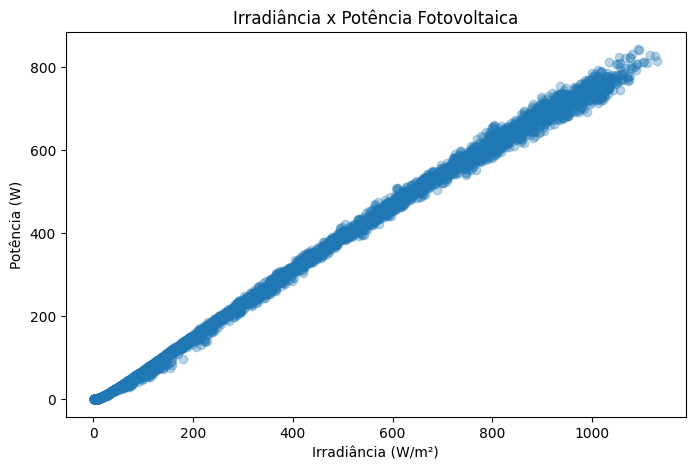

In [9]:
plt.figure(figsize=(8, 5))
plt.scatter(
    df_modelo["irradiancia"],
    df_modelo["potencia"],
    alpha=0.3
)
plt.title("Irradiância x Potência Fotovoltaica")
plt.xlabel("Irradiância (W/m²)")
plt.ylabel("Potência (W)")
plt.show()

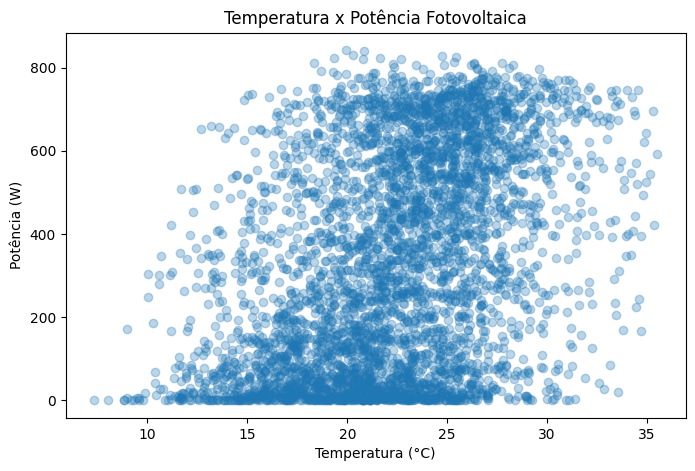

In [10]:
plt.figure(figsize=(8, 5))
plt.scatter(
    df_modelo["temperatura"],
    df_modelo["potencia"],
    alpha=0.3
)
plt.title("Temperatura x Potência Fotovoltaica")
plt.xlabel("Temperatura (°C)")
plt.ylabel("Potência (W)")
plt.show()

## 7. Matriz de correlação

A matriz de correlação será utilizada para verificar a intensidade e a direção das relações lineares entre as variáveis numéricas.

In [11]:
correlacao = df_modelo[
    ["potencia", "irradiancia", "temperatura", "vento", "altura_solar"]
].corr()

display(correlacao)

,potencia,irradiancia,temperatura,vento,altura_solar
potencia,1.000000,0.998533,0.400712,0.034327,0.686365
irradiancia,0.998533,1.000000,0.422532,0.018944,0.692615
temperatura,0.400712,0.422532,1.000000,0.137871,0.487116
vento,0.034327,0.018944,0.137871,1.000000,0.205481
altura_solar,0.686365,0.692615,0.487116,0.205481,1.000000


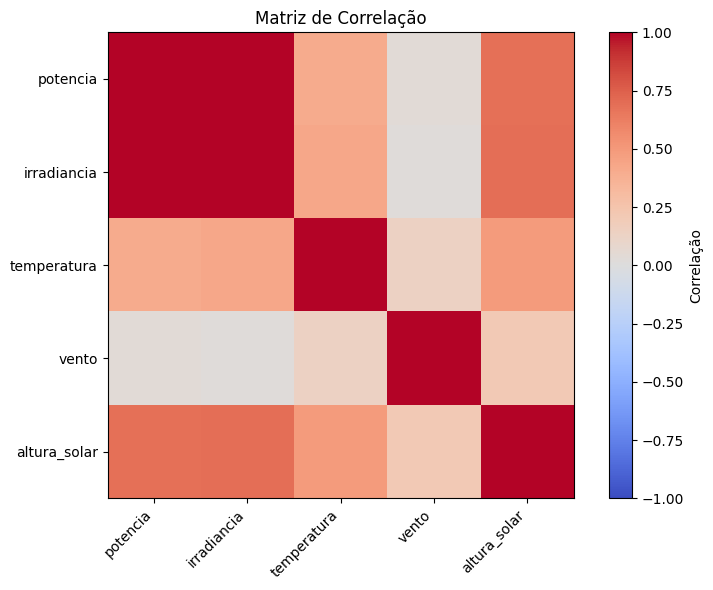

In [12]:
plt.figure(figsize=(8, 6))
plt.imshow(correlacao, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="Correlação")
plt.xticks(
    range(len(correlacao.columns)),
    correlacao.columns,
    rotation=45,
    ha="right"
)
plt.yticks(
    range(len(correlacao.columns)),
    correlacao.columns
)
plt.title("Matriz de Correlação")
plt.tight_layout()
plt.show()

In [13]:
print("Correlação das variáveis com a potência:")
display(correlacao["potencia"].sort_values(ascending=False))

Correlação das variáveis com a potência:


,potencia
potencia,1.000000
irradiancia,0.998533
altura_solar,0.686365
temperatura,0.400712
vento,0.034327


### Análise da correlação

A variável que apresentar a maior correlação linear com a potência será identificada a partir da tabela acima. A interpretação final deve considerar também os gráficos de dispersão e os resultados dos modelos.

## 8. Separação entre treinamento e teste

Serão reservados 20% dos dados para teste. O `random_state=42` será utilizado para tornar o experimento reproduzível.

## 9. Modelo 1 — Irradiância e temperatura

O primeiro modelo utilizará irradiância e temperatura como variáveis de entrada.

In [14]:
X1 = df_modelo[["irradiancia", "temperatura"]]
y1 = df_modelo["potencia"]

X_train1, X_test1, y_train1, y_test1 = train_test_split(
    X1,
    y1,
    test_size=0.20,
    random_state=42
)

print("X_train1:", X_train1.shape)
print("X_test1:", X_test1.shape)
print("y_train1:", y_train1.shape)
print("y_test1:", y_test1.shape)

X_train1: (3448, 2)
X_test1: (862, 2)
y_train1: (3448,)
y_test1: (862,)


In [15]:
modeloLR1 = LinearRegression()
modeloLR1.fit(X_train1, y_train1)

y_pred1 = modeloLR1.predict(X_test1)

mae1 = mean_absolute_error(y_test1, y_pred1)
mse1 = mean_squared_error(y_test1, y_pred1)
r2_1 = r2_score(y_test1, y_pred1)

print("MODELO 1")
print("MAE:", mae1)
print("MSE:", mse1)
print("R²:", r2_1)

MODELO 1
MAE: 9.19494930412532
MSE: 146.829346048463
R²: 0.9977484407690804


## 10. Modelo 2 — Irradiância, temperatura, vento e altura solar

O segundo modelo utilizará um conjunto maior de variáveis para verificar se a inclusão de novas informações melhora o desempenho.

In [16]:
X2 = df_modelo[
    ["irradiancia", "temperatura", "vento", "altura_solar"]
]
y2 = df_modelo["potencia"]

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X2,
    y2,
    test_size=0.20,
    random_state=42
)

print("X_train2:", X_train2.shape)
print("X_test2:", X_test2.shape)
print("y_train2:", y_train2.shape)
print("y_test2:", y_test2.shape)

X_train2: (3448, 4)
X_test2: (862, 4)
y_train2: (3448,)
y_test2: (862,)


In [17]:
modeloLR2 = LinearRegression()
modeloLR2.fit(X_train2, y_train2)

y_pred2 = modeloLR2.predict(X_test2)

mae2 = mean_absolute_error(y_test2, y_pred2)
mse2 = mean_squared_error(y_test2, y_pred2)
r2_2 = r2_score(y_test2, y_pred2)

print("MODELO 2")
print("MAE:", mae2)
print("MSE:", mse2)
print("R²:", r2_2)

MODELO 2
MAE: 8.849395225071364
MSE: 121.98526909576898
R²: 0.9981294130494994


## 11. Comparação dos modelos

Os resultados serão organizados em uma tabela comparativa com as variáveis utilizadas e as métricas MAE, MSE e R².

In [18]:
comparacao = pd.DataFrame({
    "Modelo": ["Modelo 1", "Modelo 2"],
    "Variáveis utilizadas": [
        "Irradiância, Temperatura",
        "Irradiância, Temperatura, Vento, Altura Solar"
    ],
    "MAE": [mae1, mae2],
    "MSE": [mse1, mse2],
    "R²": [r2_1, r2_2]
})

display(comparacao)

,Modelo,Variáveis utilizadas,MAE,MSE,R²
0,Modelo 1,"Irradiância, Temperatura",9.194949,146.829346,0.997748
1,Modelo 2,"Irradiância, Temperatura, Vento, Altura Solar",8.849395,121.985269,0.998129


## 12. Respostas da atividade 11



In [19]:
melhor_r2 = "Modelo 1" if r2_1 > r2_2 else "Modelo 2"
menor_mae = "Modelo 1" if mae1 < mae2 else "Modelo 2"
menor_mse = "Modelo 1" if mse1 < mse2 else "Modelo 2"

print("1. Modelo com maior R²:", melhor_r2)
print("2. Modelo com menor MAE:", menor_mae)
print("3. Modelo com menor MSE:", menor_mse)

if melhor_r2 == menor_mae == menor_mse:
    print("4. As três métricas apontam para o mesmo modelo como melhor opção: SIM.")
else:
    print("4. As três métricas apontam para o mesmo modelo como melhor opção: NÃO.")

print("\n5. A variável com maior correlação com a potência pode ser identificada na matriz de correlação acima.")
print("6. A existência de relações aproximadamente lineares deve ser avaliada pelos gráficos de dispersão.")
print("7. Fatores que podem dificultar a previsão incluem variações da irradiância, temperatura, condições atmosféricas e características do sistema fotovoltaico.")

1. Modelo com maior R²: Modelo 2
2. Modelo com menor MAE: Modelo 2
3. Modelo com menor MSE: Modelo 2
4. As três métricas apontam para o mesmo modelo como melhor opção: SIM.

5. A variável com maior correlação com a potência pode ser identificada na matriz de correlação acima.
6. A existência de relações aproximadamente lineares deve ser avaliada pelos gráficos de dispersão.
7. Fatores que podem dificultar a previsão incluem variações da irradiância, temperatura, condições atmosféricas e características do sistema fotovoltaico.


## 13. Conclusão

Foram desenvolvidos dois modelos de Regressão Linear para estimar a potência fotovoltaica em São Paulo. O Modelo 1 utilizou irradiância e temperatura, enquanto o Modelo 2 utilizou irradiância, temperatura, velocidade do vento e altura solar.

Os modelos foram avaliados por meio das métricas MAE, MSE e R². O melhor modelo será aquele que apresentar menor MAE e MSE e maior R². A comparação permite verificar se a inclusão de novas variáveis melhora a capacidade de previsão da potência fotovoltaica.

A irradiância solar é uma variável importante para explicar a potência gerada. Entretanto, outros fatores podem influenciar a produção fotovoltaica e dificultar uma previsão perfeitamente linear.